# EDA 04: Proteomics (Mass Spectrometry)

## Purpose

`4_Harmonized_MS_CCLE_Gygi_subsetted.csv` measures **proteins**, not transcripts — despite living in
the `gene_expression/` folder. RNA (notebooks 01–03) tells us what a cell is instructing; this
tells us what it actually built. Drug targets are proteins, so this layer sits closer to
mechanism — at the cost of being the smallest-coverage primary layer.

**Source, release, grain:** CCLE/Gygi-lab mass spectrometry proteomics, harmonized. Wide format —
row = `ModelID`, column = protein. ~375 cell lines × 12,558 proteins.

## Questions this notebook must answer

1. Is the row index really `ModelID`, joinable directly to the primary spine (file 9)?
2. Is missingness here structured (bimodal — detected vs. not) rather than random?
3. What do the values mean — a strict z-score, or something else?
4. Which proteins carry the most cross-line signal?
5. How much of the primary spine does this layer actually cover, and is that coverage
   lineage-biased?
6. For genes measured in both RNA (notebook 02) and here, how well does RNA predict protein —
   is this layer redundant with RNA, or does it add independent information?

**Interpretation rule:** a numeric value is `measured`. `NaN` here is `measured_absent` — the assay
ran (mass spec was performed on that cell line) but the protein was not detected, a real
biological floor-of-detection reading, not a missing measurement in the ordinary sense
(`docs/PROJECT_ARCHITECTURE.md` §7). A `ModelID` absent from this table entirely is `not_assayed`
for proteomics.

## Column dictionary

| Field | Meaning | Notes |
|---|---|---|
| row index (`Unnamed: 0`) | DepMap `ModelID` (`ACH-...`) | direct 1:1 key to file 9 — no bridge needed |
| columns | `UniProt (SYMBOL)` per protein | |
| cell values | harmonized relative abundance | centred near 0 but **not** unit-variance — standardised, not a strict z-score |

## 1. Basic data contract and schema audit

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'gene_expression'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

In [2]:
df = pd.read_csv(GENE_EXPRESSION / '4_Harmonized_MS_CCLE_Gygi_subsetted.csv')
df = df.rename(columns={'Unnamed: 0': 'ModelID'}).set_index('ModelID')
print(f"Cell lines (rows): {len(df)}")
print(f"Proteins (cols)  : {df.shape[1]}")
df.iloc[:3, :4]

Cell lines (rows): 375
Proteins (cols)  : 12558


,A0AV96 (RBM47),A0AVF1 (IFT56),A0AVG3 (TSNARE1),A0AVI4 (TMEM129)
ModelID,,,,
ACH-000849,0.358567,-0.172066,NaN,NaN
ACH-000441,-1.112410,0.339446,NaN,NaN
ACH-000248,0.855575,-0.181171,NaN,NaN


### Why this EDA check matters

Confirms this table is mis-filed by folder name (`gene_expression/`) but correctly a proteomics
layer, and that the row index is directly `ModelID` — the only primary layer with a single-hop join
to the identity spine.

## 2. Missingness — the bimodal detection pattern

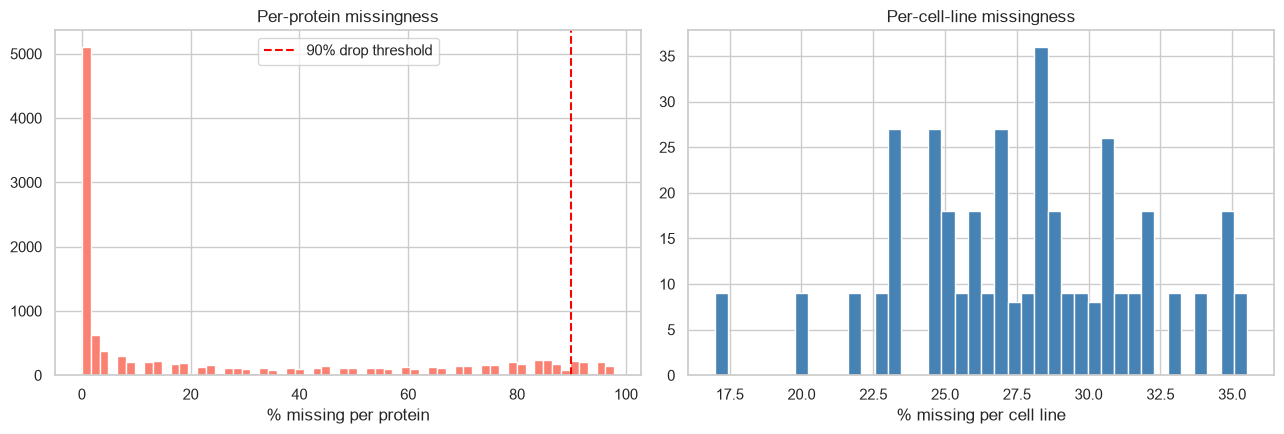

Proteins >90% missing (drop candidates): 834 of 12558


In [3]:
pct_missing_per_protein = df.isnull().mean() * 100
pct_missing_per_line = df.isnull().mean(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(pct_missing_per_protein, bins=60, color='salmon', edgecolor='white')
axes[0].axvline(90, color='red', linestyle='--', label='90% drop threshold')
axes[0].set_xlabel('% missing per protein'); axes[0].set_title('Per-protein missingness')
axes[0].legend()
axes[1].hist(pct_missing_per_line, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('% missing per cell line'); axes[1].set_title('Per-cell-line missingness')
plt.tight_layout(); plt.show()
print(f"Proteins >90% missing (drop candidates): {(pct_missing_per_protein > 90).sum()} of {df.shape[1]}")

### Why this EDA check matters

A protein missing in most cell lines is either genuinely below the mass spec's detection floor
everywhere (a real biological reading), or an assay artefact — the bimodal shape (many proteins
either almost-always or almost-never detected, few in between) is what distinguishes structured
`measured_absent` missingness from random dropout. This is exactly gap-paper 2's subject
(`docs/research/preprocessing/summary/ACCOUNTING_FOR_THE_MULTIPLE_NATURES_OF_MISSING_VALUES_...md`)
— the detection-floor imputation `impute.py` (P4) must implement, never mean-imputation.

## 3. Value distribution

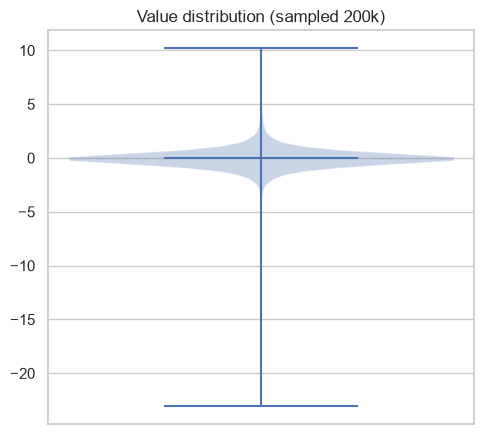

Mean: -0.028  Std: 0.964


In [4]:
vals = df.values.flatten()
vals = vals[~np.isnan(vals)]
np.random.seed(42)
sample = np.random.choice(vals, min(200_000, len(vals)), replace=False)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.violinplot(sample, showmedians=True)
ax.set_title('Value distribution (sampled 200k)'); ax.set_xticks([])
plt.tight_layout(); plt.show()
print(f"Mean: {sample.mean():.3f}  Std: {sample.std():.3f}")

### Why this EDA check matters

Confirms the "harmonized relative abundance, not strict z-score" claim in the column dictionary —
a mean near 0 with std materially different from 1 means any later per-gene desirability curve
(`docs/PROJECT_ARCHITECTURE.md` §5a) must fit its own floor/target for this layer, not reuse a
z-score assumption from elsewhere.

## 4. Per-protein variability and PCA

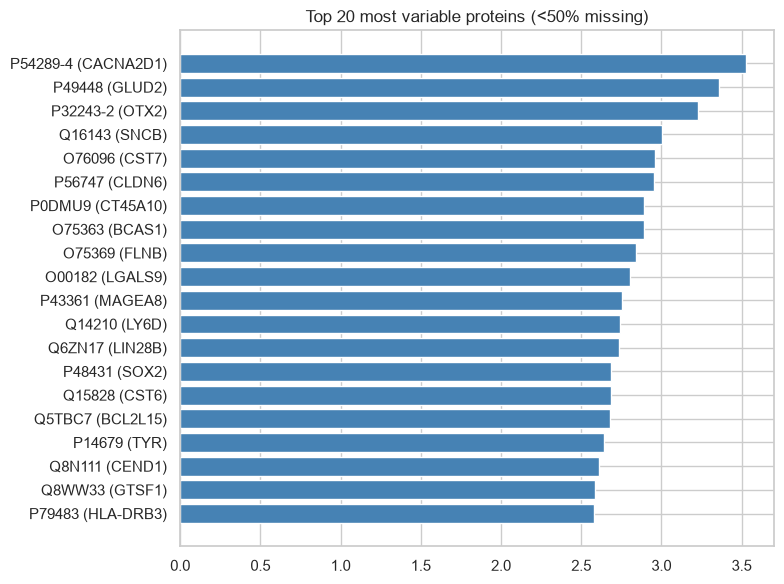

In [5]:
keep_prot = pct_missing_per_protein[pct_missing_per_protein < 50].index
prot_std = df[keep_prot].std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top20 = prot_std.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue')
ax.set_title('Top 20 most variable proteins (<50% missing)')
plt.tight_layout(); plt.show()

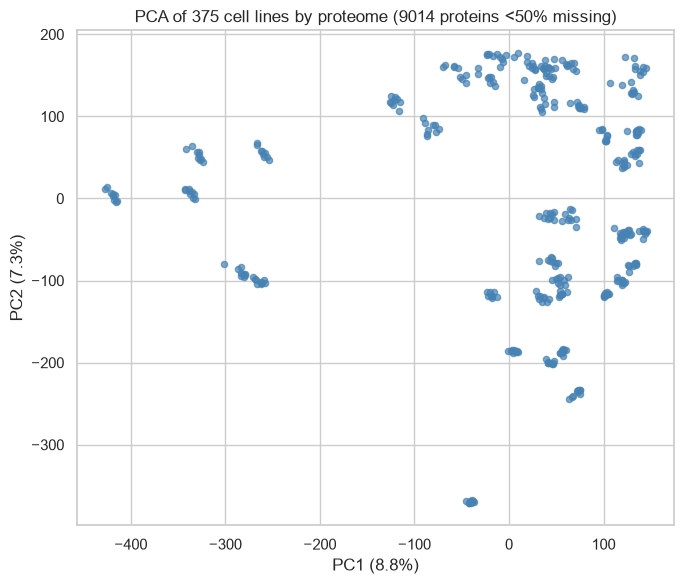

In [6]:
X_prot = df[keep_prot].fillna(df[keep_prot].min().min())
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_prot)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.7, s=20, color='steelblue')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)'); ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title(f'PCA of {len(df)} cell lines by proteome ({len(keep_prot)} proteins <50% missing)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Restricting to proteins under 50% missingness before PCA avoids the structure being an artefact of
which cell lines happen to have more detections, rather than real proteomic difference — the same
concern §2 raised, applied here to a multivariate view. **This PCA uses a floor-value fill for
visualisation only; it is not the imputation rule `impute.py` will use in production.**

## 5. Identity join path to the primary spine

In [7]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage', 'primary_disease'])

prot_models = set(df.index)
spine_models = set(df9['DepMap_ID'].dropna())
matched = prot_models & spine_models

print(f"Proteomics cell lines (this table)  : {len(prot_models)}")
print(f"Reach primary spine (file 9)        : {len(matched)} ({len(matched)/len(prot_models):.1%})")
print(f"Primary spine WITHOUT proteomics    : {len(spine_models - prot_models)} of {len(spine_models)} ({(len(spine_models)-len(matched))/len(spine_models):.1%})")

Proteomics cell lines (this table)  : 375
Reach primary spine (file 9)        : 375 (100.0%)
Primary spine WITHOUT proteomics    : 1465 of 1840 (79.6%)


### Why this EDA check matters

The row index already *is* `ModelID`, so this is the one primary layer with a genuinely 1:1,
single-hop join — but that structural simplicity does not offset its coverage: most of the primary
spine has no proteomics measurement at all, confirmed next by lineage.

## 6. Coverage bias by lineage

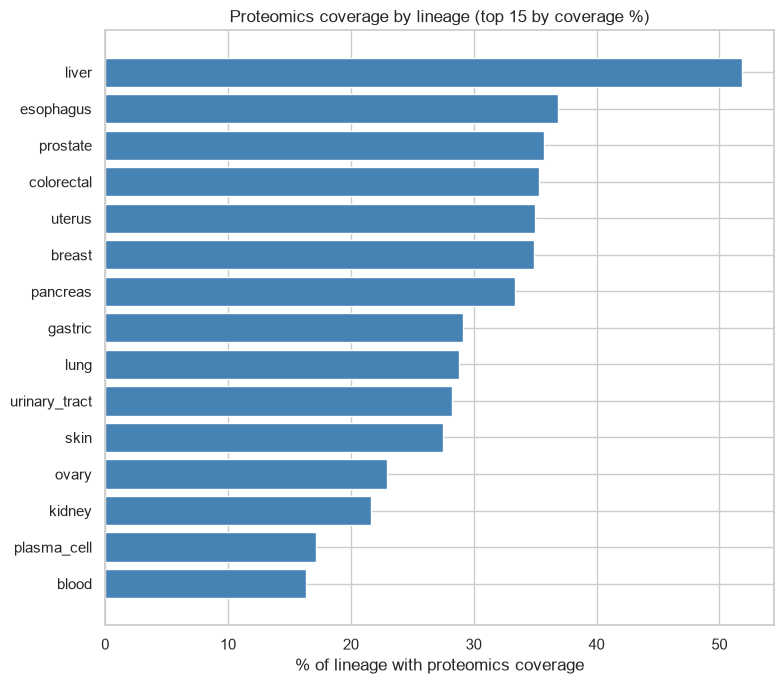

In [8]:
covered = df9[df9['DepMap_ID'].isin(matched)]
total_per_lineage = df9['lineage'].value_counts()
covered_per_lineage = covered['lineage'].value_counts()
coverage_pct = (covered_per_lineage / total_per_lineage * 100).dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
top15 = coverage_pct.head(15)
ax.barh(top15.index[::-1], top15.values[::-1], color='steelblue')
ax.set_xlabel('% of lineage with proteomics coverage')
ax.set_title('Proteomics coverage by lineage (top 15 by coverage %)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

`docs/PROJECT_ARCHITECTURE.md` §6 criterion A2 requires stating whether coverage is
lineage-biased, not just its overall fraction. Uneven per-lineage coverage means a researcher
filtering to an under-covered lineage will see proteomics abstain far more often than the ~20%
overall rate suggests — this must be disclosed on the result card, not averaged away.

## 7. Does RNA predict protein? (cross-check against notebook 02)

Drug targets are proteins, but RNA (notebook 02) is measured far more broadly. If RNA already
predicted protein levels well, proteomics would add little beyond confirming what RNA already
shows. The published expectation is a **moderate** correlation — useful as a proxy, not a
substitute — which is exactly what would justify carrying protein as an independent layer rather
than dropping it in favour of RNA alone.

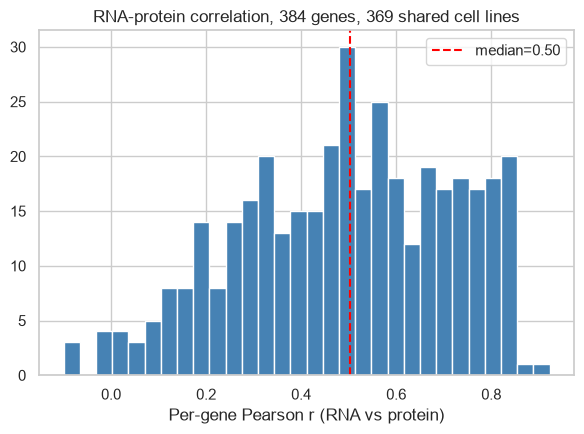

In [9]:
prot = df.copy()
prot.columns = [m.group(1) if (m := re.search(r'\(([^)]+)\)', c)) else c for c in prot.columns]
prot = prot.loc[:, ~prot.columns.duplicated()]

rna_header = pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', nrows=0).columns
sym_to_col = {}
for c in rna_header[1:]:
    sym = c.split(' (')[0]
    if sym in prot.columns and sym not in sym_to_col:
        sym_to_col[sym] = c
pick = list(sym_to_col.values())[:400]

rna = pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv',
                   usecols=[rna_header[0]] + pick).rename(columns={rna_header[0]: 'ProfileID'})
df8 = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv', usecols=['ProfileID', 'ModelID', 'Datatype'])
rna_by_model = (df8[df8['Datatype'] == 'rna']
                .merge(rna, on='ProfileID')
                .drop_duplicates('ModelID')
                .set_index('ModelID'))

shared_models = list(set(rna_by_model.index) & set(prot.index))
shared_syms = [s for s, c in sym_to_col.items() if c in pick]

corrs = []
for sym in shared_syms:
    rna_col = sym_to_col[sym]
    x = rna_by_model.loc[shared_models, rna_col]
    y = prot.loc[shared_models, sym]
    ok = x.notna() & y.notna()
    if ok.sum() > 30:
        corrs.append(x[ok].corr(y[ok]))

corrs = pd.Series(corrs).dropna()
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(corrs, bins=30, color='steelblue', edgecolor='white')
ax.axvline(corrs.median(), color='red', linestyle='--', label=f'median={corrs.median():.2f}')
ax.set_xlabel('Per-gene Pearson r (RNA vs protein)'); ax.set_title(f'RNA-protein correlation, {len(corrs)} genes, {len(shared_models)} shared cell lines')
ax.legend(); plt.tight_layout(); plt.show()

### Why this EDA check matters

A median correlation clearly above 0 but well short of 1 (matching the published moderate-agreement
literature) is the evidence that proteomics is neither redundant with RNA nor unrelated to it —
this is the concrete, small-scale version of the DNA→RNA→protein consistency chain that a future
cross-layer notebook will run at full scale. **Correlation only** — this does not establish that
either measurement is more "correct" for any individual gene, per root `_.md` §3.

## Decisions carried into the next notebooks

1. **`NaN` here is `measured_absent`, structured (bimodal), not random** — detection-floor
   imputation only, never mean-imputation (P1 gap paper 2; `preprocessing/impute.py`, P4).
2. Row index is already `ModelID` — the simplest join of any primary layer, but the
   **smallest-coverage** one (~20% of the spine, §5).
3. Coverage is lineage-biased (§6) — must be disclosed per-lineage, not just as one overall
   percentage.
4. RNA is a **moderate, imperfect proxy** for protein (§7) — proteomics is worth carrying as an
   independent scored layer where it is measured, and RNA should not silently stand in where
   proteomics is `not_assayed`.
5. **Limitation:** the RNA-protein correlation in §7 uses only the first 400 shared genes for
   runtime reasons — a production estimate would use the full shared gene set.